# **Imports**

In [23]:
import os
import sys
import json
import time
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings("ignore")

sys.path.append("../../")
from dataset_utils import CassavaDataset

# Fix all random seeds for reproducible results across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if hasattr(torch, "xpu") and torch.xpu.is_available():
    device = torch.device("xpu")
    torch.xpu.manual_seed_all(SEED)
    print("Using device: Intel XPU ->", torch.xpu.get_device_name(0))
elif torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    print("Using device: CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

Using device: Intel XPU -> Intel(R) Arc(TM) A770 Graphics


# **Data Loading**

In [24]:
BASE_DIR = "../../data"
TRAIN_DIR = os.path.join(BASE_DIR, "train_images")

df = pd.read_csv(os.path.join(BASE_DIR, "train.csv"))

with open(os.path.join(BASE_DIR, "label_num_to_disease_map.json")) as f:
    label_map = json.load(f)
label_map = {int(k): v for k, v in label_map.items()}

df["disease_name"] = df["label"].map(label_map)
num_classes = df["label"].nunique()
class_names = [label_map[i] for i in range(num_classes)]

print("Total images:", len(df))
print("Classes:", class_names)

Total images: 21397
Classes: ['Cassava Bacterial Blight (CBB)', 'Cassava Brown Streak Disease (CBSD)', 'Cassava Green Mottle (CGM)', 'Cassava Mosaic Disease (CMD)', 'Healthy']


# **Train/Val/Test Split**

In [25]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("\nTrain class distribution:")
print(train_df["label"].value_counts().sort_index())

Train: 14977 Val: 3210 Test: 3210

Train class distribution:
label
0     761
1    1532
2    1670
3    9210
4    1804
Name: count, dtype: int64


# **Augmentation + Datasets + DataLoaders (with WeightedRandomSampler)**

In [26]:
IMG_SIZE = 260

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CassavaDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset = CassavaDataset(val_df, TRAIN_DIR, transform=eval_transform)
test_dataset = CassavaDataset(test_df, TRAIN_DIR, transform=eval_transform)

BATCH_SIZE = 24

# WeightedRandomSampler handles class imbalance by oversampling minority
# classes within each batch (replaces class-weighted loss, don't use both)
class_sample_counts = train_df["label"].value_counts().sort_index().values
sample_weights = [1.0 / class_sample_counts[label] for label in train_df["label"]]
sample_weights = torch.DoubleTensor(sample_weights)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=4, persistent_workers=True, pin_memory=True,
                           drop_last=True)  # drop_last avoids BatchNorm1d crashing on a size-1 last batch

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, persistent_workers=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, persistent_workers=True, pin_memory=True)

print("Batches -> Train:", len(train_loader), "Val:", len(val_loader), "Test:", len(test_loader))

Batches -> Train: 624 Val: 134 Test: 134


# **Attention Modules**

In [27]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(in_channels // reduction_ratio, in_channels)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.mlp(self.avg_pool(x).view(b, c))
        max_out = self.mlp(self.max_pool(x).view(b, c))
        weights = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * weights


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        weights = self.sigmoid(self.conv(combined))
        return x * weights


class DualAttentionBlock(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16, spatial_kernel=7):
        super(DualAttentionBlock, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_attention = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

# **AttenLeafNetV2 Model Definition**

In [28]:
class AttenLeafNetV2(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super(AttenLeafNetV2, self).__init__()

        base_model = models.efficientnet_b0(weights="IMAGENET1K_V1" if pretrained else None)
        self.backbone = base_model.features

        backbone_out_channels = 1280

        self.attention = DualAttentionBlock(in_channels=backbone_out_channels,
                                             reduction_ratio=16, spatial_kernel=7)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(backbone_out_channels, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.attention(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def forward_with_attention_map(self, x):
        features = self.backbone(x)
        channel_refined = self.attention.channel_attention(features)
        avg_out = torch.mean(channel_refined, dim=1, keepdim=True)
        max_out, _ = torch.max(channel_refined, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        attention_map = torch.sigmoid(self.attention.spatial_attention.conv(combined))
        spatial_refined = channel_refined * attention_map
        pooled = self.global_pool(spatial_refined)
        out = self.classifier(torch.flatten(pooled, 1))
        return out, attention_map

# sanity check
test_model = AttenLeafNetV2(num_classes=num_classes)
sample = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
print("Output shape:", test_model(sample).shape)

Output shape: torch.Size([2, 5])


# **Training Helper Functions**

In [29]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def get_model_size_mb(model):
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / (1024 ** 2)

def train_one_epoch(model, loader, optimizer, criterion, epoch_num, total_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch_num}/{total_epochs} [Train]", leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{correct/total:.4f}"})

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, desc="Val"):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    pbar = tqdm(loader, desc=f"[{desc}]", leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)

    return avg_loss, acc, f1, precision, recall, per_class_recall, all_preds, all_labels

# **Stable Training Function (ReduceLROnPlateau + Early Stopping)**

In [30]:
def run_training_stable(model, model_name, max_epochs=40, lr=0.0003, patience=8):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()  # sampler already handles imbalance, no need for class weights too
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

    best_f1 = 0.0
    best_state = None
    epochs_no_improve = 0
    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, epoch, max_epochs)
        val_loss, val_acc, val_f1, val_prec, val_rec, _, _, _ = evaluate(model, val_loader, criterion, "Validation")

        scheduler.step(val_f1)
        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"[{model_name}] Epoch {epoch}/{max_epochs} ({epoch_time:.1f}s) | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} Macro-F1: {val_f1:.4f} | LR: {current_lr:.6f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch} (best Macro-F1: {best_f1:.4f})")
                break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time

    test_loss, test_acc, test_f1, test_prec, test_rec, test_per_class_recall, test_preds, test_labels = evaluate(model, test_loader, criterion, "Test")

    total_params = count_parameters(model)
    model_size = get_model_size_mb(model)

    results = {
        "model_name": model_name, "test_f1_macro": test_f1, "test_recall_macro": test_rec,
        "test_precision_macro": test_prec, "test_accuracy": test_acc,
        "test_per_class_recall": test_per_class_recall, "training_time_sec": training_time,
        "total_params": total_params, "model_size_mb": model_size, "history": history,
        "test_preds": test_preds, "test_labels": test_labels
    }

    print(f"\n[{model_name}] FINAL TEST -> Macro-F1: {test_f1:.4f} | Accuracy: {test_acc:.4f} | "
          f"Params: {total_params:,} | Time: {training_time:.1f}s\n")

    return model, results

# **Final Model Train**

In [31]:
atten_leaf_net_final = AttenLeafNetV2(num_classes=num_classes, pretrained=True)

print("Final stable training run")
atten_leaf_net_final, final_results = run_training_stable(
    atten_leaf_net_final, "AttenLeafNetV2_Final", max_epochs=40, lr=0.0003, patience=8
)

Final stable training run


Epoch 1/40 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/134 [00:00<?, ?it/s]

[AttenLeafNetV2_Final] Epoch 1/40 (119.2s) | Train Loss: 0.9135 Acc: 0.6513 | Val Loss: 0.5458 Acc: 0.8181 Macro-F1: 0.7170 | LR: 0.000300


Epoch 2/40 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

...

Epoch 21/40 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/134 [00:00<?, ?it/s]

[AttenLeafNetV2_Final] Epoch 21/40 (104.2s) | Train Loss: 0.1236 Acc: 0.9566 | Val Loss: 0.6914 Acc: 0.8417 Macro-F1: 0.7254 | LR: 0.000037
Early stopping triggered at epoch 21 (best Macro-F1: 0.7360)


[Test]:   0%|          | 0/134 [00:00<?, ?it/s]


[AttenLeafNetV2_Final] FINAL TEST -> Macro-F1: 0.7298 | Accuracy: 0.8442 | Params: 4,873,268 | Time: 2226.3s



# **Training Curves + Save Model**

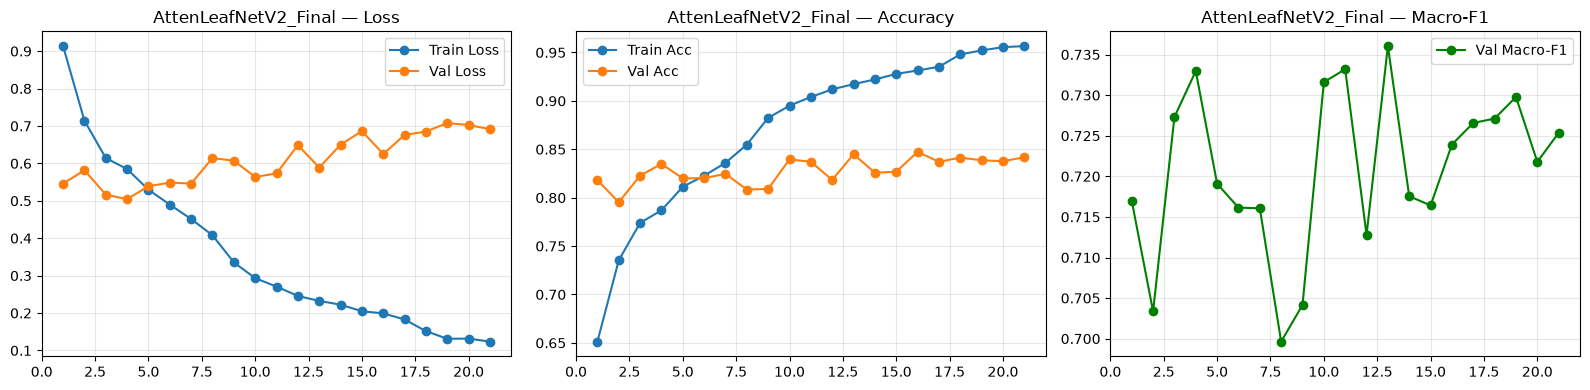

Model saved: attenleafnet_v2_final.pth


In [32]:
def plot_training_curves(history, model_name):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
    axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker="o")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
    axes[1].plot(epochs_range, history["val_acc"], label="Val Acc", marker="o")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs_range, history["val_f1"], label="Val Macro-F1", marker="o", color="green")
    axes[2].set_title(f"{model_name} — Macro-F1")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{model_name}_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_training_curves(final_results["history"], "AttenLeafNetV2_Final")

torch.save(atten_leaf_net_final.state_dict(), "attenleafnet_v2_final.pth")
print("Model saved: attenleafnet_v2_final.pth")

# **Confusion Matrix + Classification Report**

              precision    recall  f1-score   support

         CBB       0.56      0.58      0.57       163
        CBSD       0.75      0.72      0.74       329
         CGM       0.71      0.78      0.74       358
         CMD       0.95      0.93      0.94      1974
     Healthy       0.64      0.68      0.66       386

    accuracy                           0.84      3210
   macro avg       0.72      0.74      0.73      3210
weighted avg       0.85      0.84      0.85      3210



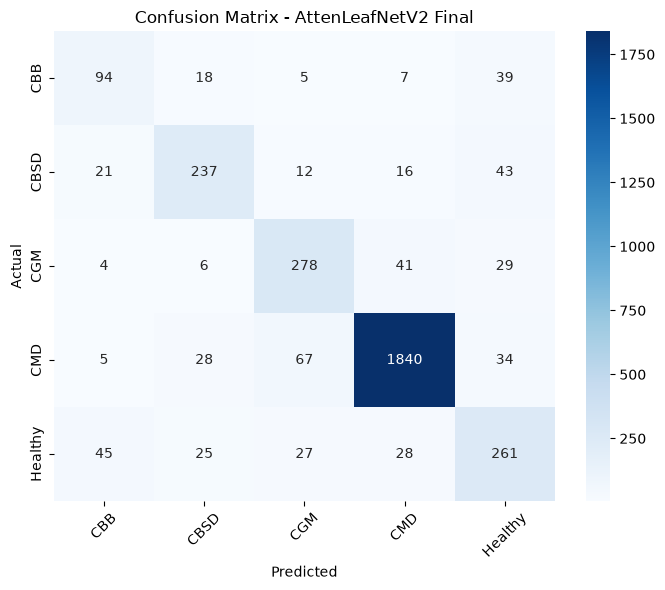

In [33]:

short_class_names = ["CBB", "CBSD", "CGM", "CMD", "Healthy"] 


print(classification_report(final_results["test_labels"], final_results["test_preds"], target_names=short_class_names))

cm = confusion_matrix(final_results["test_labels"], final_results["test_preds"])
plt.figure(figsize=(7, 6))


sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=short_class_names, yticklabels=short_class_names)

plt.title("Confusion Matrix - AttenLeafNetV2 Final")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("final_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# **5-Fold Cross Validation**

In [34]:
cv_df = pd.concat([train_df, val_df]).reset_index(drop=True)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1_scores = []
cv_acc_scores = []
fold_num = 1

for train_idx, val_idx in skf.split(cv_df["image_id"], cv_df["label"]):
    print(f"\n===== Fold {fold_num}/5 =====")

    fold_train_df = cv_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = cv_df.iloc[val_idx].reset_index(drop=True)

    fold_train_dataset = CassavaDataset(fold_train_df, TRAIN_DIR, transform=train_transform)
    fold_val_dataset = CassavaDataset(fold_val_df, TRAIN_DIR, transform=eval_transform)

    fold_sample_counts = fold_train_df["label"].value_counts().sort_index().values
    fold_sample_weights = [1.0 / fold_sample_counts[label] for label in fold_train_df["label"]]
    fold_sampler = WeightedRandomSampler(torch.DoubleTensor(fold_sample_weights),
                                          num_samples=len(fold_sample_weights), replacement=True)

    fold_train_loader = DataLoader(fold_train_dataset, batch_size=BATCH_SIZE, sampler=fold_sampler,
                                    num_workers=4, persistent_workers=True, pin_memory=True, drop_last=True)
    fold_val_loader = DataLoader(fold_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=4, persistent_workers=True, pin_memory=True)

    fold_model = AttenLeafNetV2(num_classes=num_classes, pretrained=True).to(device)
    fold_criterion = nn.CrossEntropyLoss()
    fold_optimizer = optim.AdamW(fold_model.parameters(), lr=0.0003, weight_decay=1e-4)

    # Shorter training per fold — CV is for checking stability, not the final model
    for epoch in range(1, 11):
        train_one_epoch(fold_model, fold_train_loader, fold_optimizer, fold_criterion, epoch, 10)

    _, fold_acc, fold_f1, _, _, _, _, _ = evaluate(fold_model, fold_val_loader, fold_criterion, f"Fold{fold_num}")

    print(f"Fold {fold_num} -> Macro-F1: {fold_f1:.4f}, Accuracy: {fold_acc:.4f}")
    cv_f1_scores.append(fold_f1)
    cv_acc_scores.append(fold_acc)
    fold_num += 1

print("\n===== 5-Fold CV Results =====")
print(f"Macro-F1: {np.mean(cv_f1_scores):.4f} ± {np.std(cv_f1_scores):.4f}")
print(f"Accuracy: {np.mean(cv_acc_scores):.4f} ± {np.std(cv_acc_scores):.4f}")


===== Fold 1/5 =====


Epoch 1/10 [Train]:   0%|          | 0/606 [00:00<?, ?it/s]

Epoch 2/10 [Train]:   0%|          | 0/606 [00:00<?, ?it/s]

Epoch 3/10 [Train]:   0%|          | 0/606 [00:00<?, ?it/s]

Epoch 4/10 [Train]:   0%|          | 0/606 [00:00<?, ?it/s]

...

Epoch 8/10 [Train]:   0%|          | 0/606 [00:00<?, ?it/s]

Epoch 9/10 [Train]:   0%|          | 0/606 [00:00<?, ?it/s]

Epoch 10/10 [Train]:   0%|          | 0/606 [00:00<?, ?it/s]

[Fold5]:   0%|          | 0/152 [00:00<?, ?it/s]

Fold 5 -> Macro-F1: 0.7332, Accuracy: 0.8249

===== 5-Fold CV Results =====
Macro-F1: 0.7156 ± 0.0143
Accuracy: 0.8175 ± 0.0136


# **Statistical Significance Test (vs Best Baseline)**

In [46]:
best_baseline_f1 = 0.7059

t_stat, p_value = stats.ttest_1samp(cv_f1_scores, best_baseline_f1)

print(f"Best Baseline (EfficientNet-B0) Macro-F1: {best_baseline_f1:.4f}")
print(f"AttenLeafNetV2 CV Macro-F1: {np.mean(cv_f1_scores):.4f} ± {np.std(cv_f1_scores):.4f}")
print(f"\nOne-sample t-test: t = {t_stat:.4f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("Result: statistically significant difference (p < 0.05)")
else:
    print("Result: NOT statistically significant (p >= 0.05)")

Best Baseline (EfficientNet-B0) Macro-F1: 0.7059
AttenLeafNetV2 CV Macro-F1: 0.7156 ± 0.0143

One-sample t-test: t = 1.3550, p = 0.2469
Result: NOT statistically significant (p >= 0.05)


# **ABLATION STUDY (all required variants)**

In [36]:
ABLATION_EPOCHS = 5
ablation_results = {}

def quick_train_eval(model, name, loader=None):
    loader_to_use = loader if loader is not None else train_loader
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    for epoch in range(1, ABLATION_EPOCHS + 1):
        train_one_epoch(model, loader_to_use, optimizer, criterion, epoch, ABLATION_EPOCHS)

    _, acc, f1, prec, rec, _, _, _ = evaluate(model, test_loader, criterion, name)
    ablation_results[name] = {"accuracy": acc, "macro_f1": f1, "precision": prec, "recall": rec}
    print(f"[{name}] Test Acc: {acc:.4f} | Macro-F1: {f1:.4f}")
    return model

In [37]:
# 1. No Attention (backbone only)
class NoAttentionModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        base = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.backbone = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(1280, num_classes)
    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

quick_train_eval(NoAttentionModel(num_classes), "No_Attention")

Epoch 1/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 3/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

[No_Attention]:   0%|          | 0/134 [00:00<?, ?it/s]

[No_Attention] Test Acc: 0.8040 | Macro-F1: 0.7043


NoAttentionModel(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
      

In [38]:
# 2. Channel Attention ONLY
class ChannelOnlyModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        base = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.backbone = base.features
        self.attention = ChannelAttention(1280)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(1280, num_classes)
    def forward(self, x):
        x = self.backbone(x)
        x = self.attention(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

quick_train_eval(ChannelOnlyModel(num_classes), "Channel_Attention_Only")

Epoch 1/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 3/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

[Channel_Attention_Only]:   0%|          | 0/134 [00:00<?, ?it/s]

[Channel_Attention_Only] Test Acc: 0.8103 | Macro-F1: 0.7160


ChannelOnlyModel(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
      

In [39]:
# 3. Spatial Attention ONLY
class SpatialOnlyModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        base = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.backbone = base.features
        self.attention = SpatialAttention(7)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(1280, num_classes)
    def forward(self, x):
        x = self.backbone(x)
        x = self.attention(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

quick_train_eval(SpatialOnlyModel(num_classes), "Spatial_Attention_Only")

Epoch 1/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 3/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

[Spatial_Attention_Only]:   0%|          | 0/134 [00:00<?, ?it/s]

[Spatial_Attention_Only] Test Acc: 0.8090 | Macro-F1: 0.7105


SpatialOnlyModel(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
      

In [40]:
# 4. Dual Attention / CBAM (full hybrid — this is the main model's attention design)
class DualAttentionModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        base = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.backbone = base.features
        self.attention = DualAttentionBlock(1280)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(1280, num_classes)
    def forward(self, x):
        x = self.backbone(x)
        x = self.attention(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

quick_train_eval(DualAttentionModel(num_classes), "Dual_Attention_CBAM")

Epoch 1/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 3/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

[Dual_Attention_CBAM]:   0%|          | 0/134 [00:00<?, ?it/s]

[Dual_Attention_CBAM] Test Acc: 0.8312 | Macro-F1: 0.7213


DualAttentionModel(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
    

In [41]:
# 5. No BatchNorm / No Dropout in classifier head
class NoRegularizationModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        base = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.backbone = base.features
        self.attention = DualAttentionBlock(1280)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(1280, num_classes)  # no dropout, no batchnorm
    def forward(self, x):
        x = self.backbone(x)
        x = self.attention(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

quick_train_eval(NoRegularizationModel(num_classes), "No_Dropout_No_BatchNorm")

Epoch 1/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 3/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

[No_Dropout_No_BatchNorm]:   0%|          | 0/134 [00:00<?, ?it/s]

[No_Dropout_No_BatchNorm] Test Acc: 0.8259 | Macro-F1: 0.7202


NoRegularizationModel(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
 

In [42]:
# 6. Fewer conv blocks — shallower backbone (first 5 feature blocks only)
class ShallowModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        base = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.backbone = nn.Sequential(*list(base.features.children())[:5])
        with torch.no_grad():
            dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
            out_channels = self.backbone(dummy).shape[1]
        self.attention = DualAttentionBlock(out_channels)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(out_channels, num_classes)
    def forward(self, x):
        x = self.backbone(x)
        x = self.attention(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

quick_train_eval(ShallowModel(num_classes), "Shallow_Fewer_ConvBlocks")

Epoch 1/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 3/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

[Shallow_Fewer_ConvBlocks]:   0%|          | 0/134 [00:00<?, ?it/s]

[Shallow_Fewer_ConvBlocks] Test Acc: 0.7735 | Macro-F1: 0.6738


ShallowModel(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [43]:
# 7. Augmentation OFF
train_dataset_noaug = CassavaDataset(train_df, TRAIN_DIR, transform=eval_transform)
train_loader_noaug = DataLoader(train_dataset_noaug, batch_size=BATCH_SIZE, shuffle=True,
                                 num_workers=4, persistent_workers=True, pin_memory=True,
                                 drop_last=True)

quick_train_eval(DualAttentionModel(num_classes), "Augmentation_OFF", loader=train_loader_noaug)

Epoch 1/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 3/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/624 [00:00<?, ?it/s]

[Augmentation_OFF]:   0%|          | 0/134 [00:00<?, ?it/s]

[Augmentation_OFF] Test Acc: 0.8399 | Macro-F1: 0.7138


DualAttentionModel(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
    

# **Ablation Summary Table + Chart**

           Configuration  Accuracy  Macro F1  Precision   Recall
     Dual_Attention_CBAM  0.831153  0.721327   0.703225 0.745026
 No_Dropout_No_BatchNorm  0.825857  0.720168   0.705033 0.741187
  Channel_Attention_Only  0.810280  0.715991   0.690556 0.754477
        Augmentation_OFF  0.839875  0.713823   0.720619 0.708872
  Spatial_Attention_Only  0.809034  0.710501   0.684356 0.750200
            No_Attention  0.804050  0.704262   0.675589 0.748253
Shallow_Fewer_ConvBlocks  0.773520  0.673834   0.639827 0.729380


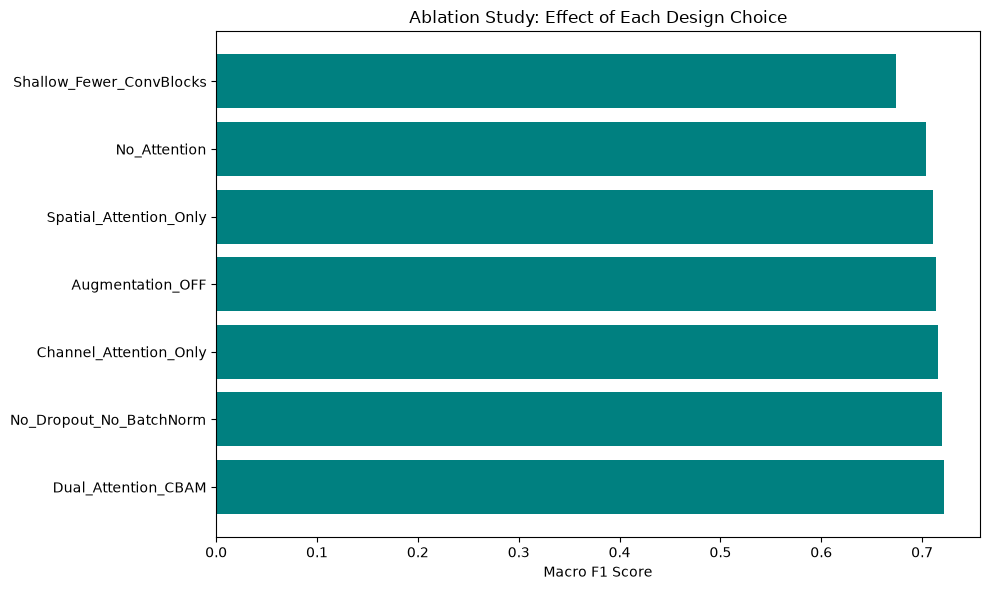

In [44]:
ablation_df = pd.DataFrame(ablation_results).T.reset_index()
ablation_df.columns = ["Configuration", "Accuracy", "Macro F1", "Precision", "Recall"]
ablation_df = ablation_df.sort_values("Macro F1", ascending=False)

print(ablation_df.to_string(index=False))
ablation_df.to_csv("ablation_study_results.csv", index=False)

plt.figure(figsize=(10, 6))
plt.barh(ablation_df["Configuration"], ablation_df["Macro F1"], color="teal")
plt.xlabel("Macro F1 Score")
plt.title("Ablation Study: Effect of Each Design Choice")
plt.tight_layout()
plt.savefig("ablation_study_chart.png", dpi=300, bbox_inches="tight")
plt.show()

# **Final Fair Comparison Table**

In [47]:
with open("../task2/baseline_results.pkl", "rb") as f:
    task2_baseline_results = pickle.load(f)

best_baseline = max(task2_baseline_results, key=lambda x: x["test_f1_macro"])

final_comparison = pd.DataFrame([
    {"Model": f"Best Baseline ({best_baseline['model_name']})",
     "Macro F1": round(best_baseline["test_f1_macro"], 4),
     "Accuracy": round(best_baseline["test_accuracy"], 4),
     "Params": f"{best_baseline['total_params']:,}"},

    {"Model": "First Model (AttenLeafNet - Task 2)",
     "Macro F1": 0.7074,
     "Accuracy": 0.8159,
     "Params": "2,759,352"},

    {"Model": "Final Model (AttenLeafNetV2 - Task 3)",
     "Macro F1": round(final_results["test_f1_macro"], 4),
     "Accuracy": round(final_results["test_accuracy"], 4),
     "Params": f"{final_results['total_params']:,}"},

    {"Model": "Related Work Best (RIPEA+EfficientNetB4, reported)",
     "Macro F1": "N/A (accuracy only reported in paper)",
     "Accuracy": "~0.9306 (reported, different split/protocol)",
     "Params": "N/A"},
])

print(final_comparison.to_string(index=False))
final_comparison.to_csv("task3_final_comparison.csv", index=False)

                                             Model                              Macro F1                                     Accuracy    Params
                   Best Baseline (EfficientNet-B0)                                0.7186                                       0.8224 4,013,953
               First Model (AttenLeafNet - Task 2)                                0.7074                                       0.8159 2,759,352
             Final Model (AttenLeafNetV2 - Task 3)                                0.7298                                       0.8442 4,873,268
Related Work Best (RIPEA+EfficientNetB4, reported) N/A (accuracy only reported in paper) ~0.9306 (reported, different split/protocol)       N/A
